In [1]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [2]:
df = pd.read_excel("./datasets/Specimens-Train.xlsx")
print(f"Data loaded. Total length: {len(df)}")

split_ratio = 0.8
split_idx   = int(split_ratio * len(df))

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

train_A = train_df["TOTAL B"].values
train_S = train_df["TOTAL SPECIMENS"].values
test_A  = test_df["TOTAL B"].values
test_S  = test_df["TOTAL SPECIMENS"].values

print(f"Train : {len(train_df)} samples  ({split_ratio*100:.0f}%)")
print(f"Test  : {len(test_df)} samples   ({(1-split_ratio)*100:.0f}%)")

Data loaded. Total length: 238
Train : 190 samples  (80%)
Test  : 48 samples   (20%)


In [3]:
def universe(series, factor=0.2):
    lo, hi = series.min(), series.max()
    d = factor * (hi - lo)
    return lo - d, hi + d

U_min_A, U_max_A = universe(train_A)
U_min_S, U_max_S = universe(train_S)

print(f"TOTAL B         → U_min={U_min_A:.4f}  U_max={U_max_A:.4f}")
print(f"TOTAL SPECIMENS → U_min={U_min_S:.4f}  U_max={U_max_S:.4f}")

TOTAL B         → U_min=-1626.2000  U_max=9820.2000
TOTAL SPECIMENS → U_min=-11517.8000  U_max=225668.8000


In [ ]:
tau = 17
m   = 3    

n = len(train_A)
N = n - (m - 1) * tau

X_A = np.zeros((N, m))
for i in range(m):
    X_A[:, i] = train_A[i*tau : i*tau + N]

X_S = np.zeros((N, m))
for i in range(m):
    X_S[:, i] = train_S[i*tau : i*tau + N]

print(f"Phase-space TOTAL B         : {X_A.shape}")
print(f"Phase-space TOTAL SPECIMENS : {X_S.shape}")

Phase-space TOTAL B         : (156, 3)
Phase-space TOTAL SPECIMENS : (156, 3)


In [5]:
c_B = 27   # ← number of clusters for TOTAL B
c_S = 31   # ← number of clusters for TOTAL SPECIMENS

print(f"Clustering TOTAL B         with c={c_B} ...")
cntr_A, u_A, *_ = fuzz.cluster.cmeans(
    X_A.T, c=c_B, m=2.0, error=0.005, maxiter=1000
)
centers_A = np.sort(cntr_A[:, 0])   # 1-D: use the first (only) lag column

print(f"Clustering TOTAL SPECIMENS with c={c_S} ...")
cntr_S, u_S, *_ = fuzz.cluster.cmeans(
    X_S.T, c=c_S, m=2.0, error=0.005, maxiter=1000
)
centers_S = np.sort(cntr_S[:, 0])   # 1-D: use the first (only) lag column

print(f"\ncenters_A  ({c_B} clusters): {centers_A}")
print(f"\ncenters_S  ({c_S} clusters): {centers_S}")

Clustering TOTAL B         with c=27 ...
Clustering TOTAL SPECIMENS with c=31 ...

centers_A  (27 clusters): [  31.19743807   45.45151164   46.24593101  109.89642709  125.84372883
  126.46358398  130.09392496  133.08141309  135.56000921  142.9101485
  153.23494732  160.61724514  170.38583764  218.92847542  236.74046486
  300.25255058  301.71291615  331.40604103  339.43972879  370.81972218
  949.31258756 1235.18224603 1346.32316574 1738.90540272 3312.54752284
 4684.25054225 5032.55066811]

centers_S  (31 clusters): [ 24222.51603454  28940.90632181  29205.88910127  33157.310827
  35829.14766734  39809.47084565  42739.26498406  48486.78811056
  51639.38346349  53388.70878598  53580.80612948  56695.8746968
  61556.7916467   63704.19792314  64163.29619909  64640.05060511
  66974.83805875  68341.62874193  70159.23372808  72060.33833327
  80396.09208159  82507.42995349  87052.65309281  94317.13659556
  95084.35179178 107301.02748027 108953.0229645  124735.83158699
 140013.30498519 154575.2573

In [6]:
def build_fuzzy_sets(centers, u_min, u_max):
    """Build triangular fuzzy sets from sorted cluster centres."""
    boundaries = [(centers[i] + centers[i+1]) / 2 for i in range(len(centers) - 1)]
    intervals  = [(u_min, boundaries[0])]
    for i in range(len(boundaries) - 1):
        intervals.append((boundaries[i], boundaries[i+1]))
    intervals.append((boundaries[-1], u_max))

    fs = []
    for i, b in enumerate(centers):
        if i == 0:
            a, c = intervals[0][0], centers[1]
        elif i == len(centers) - 1:
            a, c = centers[-2], intervals[-1][1]
        else:
            a, c = centers[i-1], centers[i+1]
        fs.append((a, b, c))
    return fs

fuzzy_sets_A = build_fuzzy_sets(centers_A, U_min_A, U_max_A)
fuzzy_sets_S = build_fuzzy_sets(centers_S, U_min_S, U_max_S)

print(f"Fuzzy sets for TOTAL B         : {len(fuzzy_sets_A)}")
print(f"Fuzzy sets for TOTAL SPECIMENS : {len(fuzzy_sets_S)}")

Fuzzy sets for TOTAL B         : 27
Fuzzy sets for TOTAL SPECIMENS : 31


In [7]:
def triangular_mf(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    return (x - a) / (b - a) if x <= b else (c - x) / (c - b)

def which_partition(value, fuzzy_sets):
    mfs  = [triangular_mf(value, *fs) for fs in fuzzy_sets]
    best = int(np.argmax(mfs))
    return None if mfs[best] == 0 else best

def fuzzify_series(values, fuzzy_sets):
    return np.array([
        (which_partition(v, fuzzy_sets) if which_partition(v, fuzzy_sets) is not None else -1)
        for v in values
    ])

print("Helper functions defined.")

Helper functions defined.


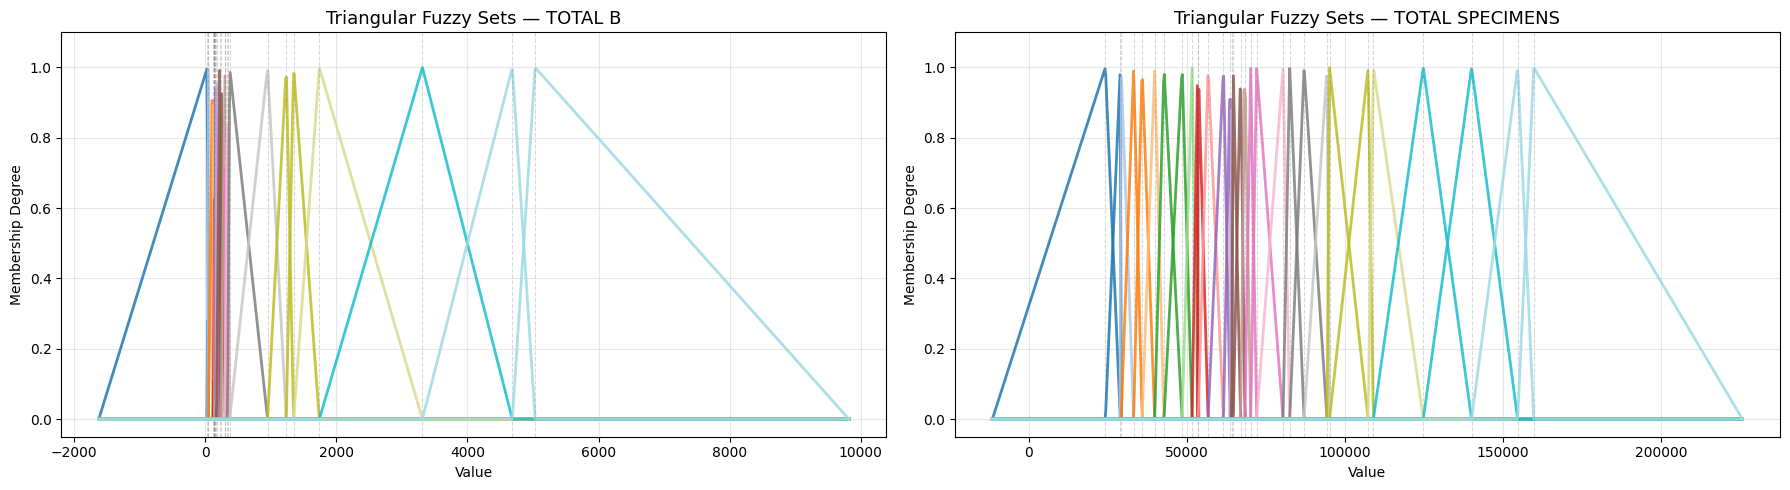

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, (fsets, u_lo, u_hi, title) in zip(
    axes,
    [
        (fuzzy_sets_A, U_min_A, U_max_A, "TOTAL B"),
        (fuzzy_sets_S, U_min_S, U_max_S, "TOTAL SPECIMENS"),
    ]
):
    x_plot = np.linspace(u_lo, u_hi, 1000)
    colors  = plt.cm.tab20(np.linspace(0, 1, len(fsets)))
    for i, (a, b, c) in enumerate(fsets):
        y = [triangular_mf(v, a, b, c) for v in x_plot]
        ax.plot(x_plot, y, color=colors[i], linewidth=2, alpha=0.85)
        ax.axvline(b, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
    ax.set_title(f"Triangular Fuzzy Sets — {title}", fontsize=13)
    ax.set_xlabel("Value")
    ax.set_ylabel("Membership Degree")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

In [9]:
all_A = df["TOTAL B"].values
all_S = df["TOTAL SPECIMENS"].values

labels_A = fuzzify_series(all_A, fuzzy_sets_A)
labels_S = fuzzify_series(all_S, fuzzy_sets_S)

labels_train_A = labels_A[:len(train_df)]
labels_train_S = labels_S[:len(train_df)]
labels_test_A  = labels_A[len(train_df):]
labels_test_S  = labels_S[len(train_df):]

print("Labels TOTAL B (first 10):", labels_train_A[:10])
print("Labels TOTAL S (first 10):", labels_train_S[:10])

Labels TOTAL B (first 10): [3 2 2 2 2 0 0 0 0 0]
Labels TOTAL S (first 10): [6 6 5 4 4 3 3 3 3 3]


In [10]:
flrg = defaultdict(lambda: defaultdict(int))

for t in range(len(labels_train_A) - 1):
    key = (labels_train_A[t], labels_train_S[t])
    rhs = labels_train_A[t + 1]
    flrg[key][rhs] += 1

print(f"FLRG entries (First-Order, multivariate): {len(flrg)}")
print()
for i, (lhs, rhs_dict) in enumerate(sorted(flrg.items())):
    rhs_str = ", ".join(f"A{r+1}({w})" for r, w in rhs_dict.items())
    print(f"  (A{lhs[0]+1}, S{lhs[1]+1})  →  {rhs_str}")


FLRG entries (First-Order, multivariate): 119

  (A1, S1)  →  A1(8)
  (A1, S2)  →  A1(4)
  (A1, S3)  →  A1(4)
  (A1, S4)  →  A1(9)
  (A1, S5)  →  A1(4)
  (A1, S6)  →  A1(3), A2(1)
  (A1, S7)  →  A1(5)
  (A1, S8)  →  A1(2), A2(1)
  (A1, S9)  →  A1(3)
  (A1, S11)  →  A1(1), A2(1)
  (A1, S12)  →  A1(2)
  (A1, S13)  →  A2(1), A1(3), A3(1)
  (A1, S14)  →  A2(1)
  (A1, S15)  →  A3(1)
  (A1, S16)  →  A1(1)
  (A1, S17)  →  A4(1)
  (A1, S19)  →  A1(1), A3(1)
  (A1, S20)  →  A2(1)
  (A1, S22)  →  A2(1)
  (A2, S6)  →  A1(1)
  (A2, S7)  →  A1(1)
  (A2, S8)  →  A1(1)
  (A2, S12)  →  A1(1)
  (A2, S13)  →  A3(1)
  (A2, S17)  →  A1(1)
  (A2, S18)  →  A3(1)
  (A2, S19)  →  A2(1)
  (A2, S20)  →  A2(1), A3(1)
  (A2, S21)  →  A3(1)
  (A2, S22)  →  A3(1)
  (A3, S5)  →  A3(1), A1(1)
  (A3, S6)  →  A3(1), A2(1)
  (A3, S7)  →  A3(1)
  (A3, S13)  →  A3(1), A1(2)
  (A3, S14)  →  A1(1)
  (A3, S16)  →  A3(1)
  (A3, S17)  →  A4(1)
  (A3, S20)  →  A2(1)
  (A3, S21)  →  A3(1), A1(1)
  (A3, S22)  →  A1(1)
  (A3, S23)

In [11]:
order = 2

flrg_ho = defaultdict(lambda: defaultdict(int))

for t in range(order, len(labels_train_A)):
    lhs = tuple(
        labels_train_A[t - order + i] if j == 0 else labels_train_S[t - order + i]
        for i in range(order)
        for j in range(2)
    )
    rhs = labels_train_A[t]
    flrg_ho[lhs][rhs] += 1

print(f"High-order FLRG entries (order={order}, multivariate): {len(flrg_ho)}")
print()
for i, (lhs, rhs_dict) in enumerate(sorted(flrg_ho.items())[:5]):
    pair_str = ", ".join(
        f"(A{lhs[2*k]+1},S{lhs[2*k+1]+1})" for k in range(order)
    )
    rhs_str = ", ".join(f"A{r+1}({w})" for r, w in rhs_dict.items())
    print(f"  [{pair_str}]  →  {rhs_str}")

High-order FLRG entries (order=2, multivariate): 168

  [(A1,S1), (A1,S1)]  →  A1(7)
  [(A1,S1), (A1,S2)]  →  A1(1)
  [(A1,S2), (A1,S1)]  →  A1(1)
  [(A1,S2), (A1,S2)]  →  A1(1)
  [(A1,S2), (A1,S3)]  →  A1(1)


In [ ]:
def centroid_defuzz(rhs_dict, centers):
    if not rhs_dict:
        return np.nan
    num = sum(centers[idx] * w for idx, w in rhs_dict.items())
    den = sum(rhs_dict.values())
    return num / den


def predict_fofts_mv(t, labels_A, labels_S, flrg, centers_A, fuzzy_sets_A):
    key = (labels_A[t], labels_S[t])
    if key in flrg and flrg[key]:
        return centroid_defuzz(flrg[key], centers_A)
    merged = defaultdict(int)
    for k, rhs_dict in flrg.items():
        if k[0] == labels_A[t]:
            for r, w in rhs_dict.items():
                merged[r] += w
    return centroid_defuzz(merged, centers_A) if merged else centers_A[labels_A[t]]


def predict_hofts_mv(t, labels_A, labels_S, flrg_ho, centers_A, order):
    lhs = tuple(
        labels_A[t - order + i] if j == 0 else labels_S[t - order + i]
        for i in range(order)
        for j in range(2)
    )
    if lhs in flrg_ho and flrg_ho[lhs]:
        return centroid_defuzz(flrg_ho[lhs], centers_A)
    fallback_key = tuple(labels_A[t - order + i] for i in range(order))
    merged = defaultdict(int)
    for k, rhs_dict in flrg_ho.items():
        if tuple(k[2*i] for i in range(order)) == fallback_key:
            for r, w in rhs_dict.items():
                merged[r] += w
    return centroid_defuzz(merged, centers_A) if merged else centers_A[labels_A[t]]


print("Prediction functions defined.")

Prediction functions defined.


In [ ]:
pred_fofts = np.array([
    predict_fofts_mv(t, labels_test_A, labels_test_S,
                     flrg, centers_A, fuzzy_sets_A)
    for t in range(len(test_A) - 1)
])
actual_fofts = test_A[1:]

pred_hofts = np.array([
    predict_hofts_mv(t, labels_test_A, labels_test_S,
                     flrg_ho, centers_A, order)
    for t in range(order, len(test_A))
])
actual_hofts = test_A[order:]

print(f"FOFTS predictions : {len(pred_fofts)}  samples")
print(f"HOFTS predictions : {len(pred_hofts)}  samples")

FOFTS predictions : 47  samples
HOFTS predictions : 46  samples


In [14]:
def compute_metrics(y_true, y_pred, name="Model"):
    mse  = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_true - y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2   = r2_score(y_true, y_pred)
    acc  = 100 - mape

    print(f"\n{name}")
    print(f"   MSE      = {mse:10.6f}")
    print(f"   RMSE     = {rmse:10.4f}")
    print(f"   MAE      = {mae:10.4f}")
    print(f"   MAPE     = {mape:10.3f} %")
    print(f"   R²       = {r2:10.4f}")
    print(f"   Accuracy = {acc:10.3f} %")
    return mse, rmse, mae, mape, r2, acc

print("=" * 60)
print("   TEST SET — MULTIVARIATE FTS  (TOTAL B + TOTAL SPECIMENS)")
print("=" * 60)

m_fofts = compute_metrics(actual_fofts, pred_fofts,
                           "FOFTS (multivariate, one-step)")
m_hofts = compute_metrics(actual_hofts, pred_hofts,
                           f"HOFTS (multivariate, order={order}, one-step)")

best = "HOFTS" if m_hofts[0] < m_fofts[0] else "FOFTS"
print("\n" + "-" * 60)
print(f"Best model → {best}")
print("-" * 60)

   TEST SET — MULTIVARIATE FTS  (TOTAL B + TOTAL SPECIMENS)

FOFTS (multivariate, one-step)
   MSE      = 171635.418391
   RMSE     =   414.2891
   MAE      =   246.4306
   MAPE     =     29.756 %
   R²       =     0.9068
   Accuracy =     70.244 %

HOFTS (multivariate, order=2, one-step)
   MSE      = 174451.231637
   RMSE     =   417.6736
   MAE      =   244.1482
   MAPE     =     24.655 %
   R²       =     0.9059
   Accuracy =     75.345 %

------------------------------------------------------------
Best model → FOFTS
------------------------------------------------------------


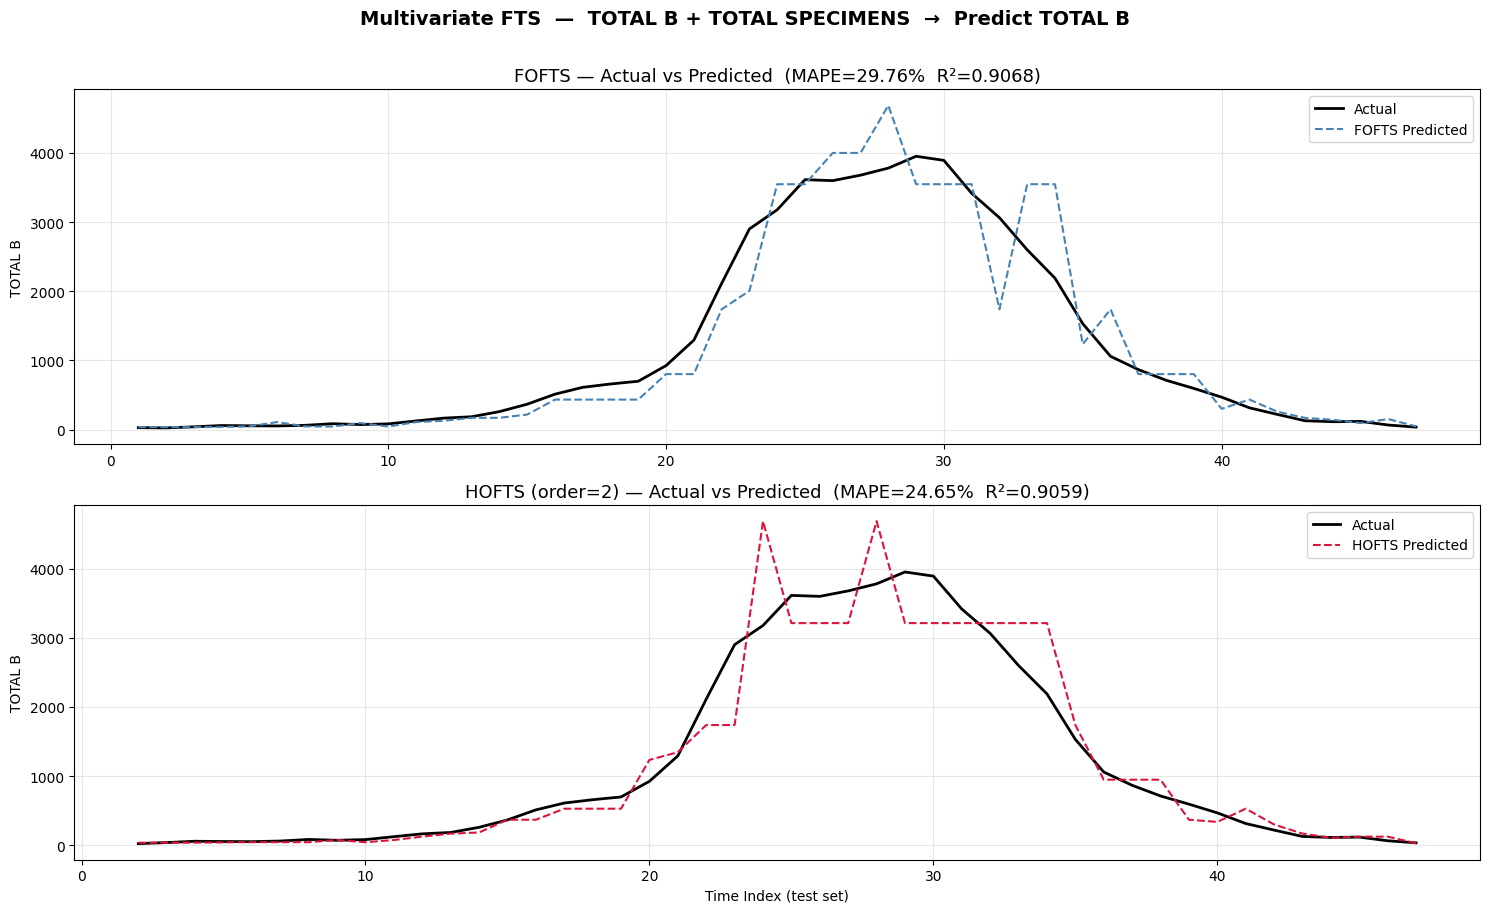

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)

ax = axes[0]
t_fo = np.arange(1, len(test_A))
ax.plot(t_fo, actual_fofts, label="Actual",          color="black",    linewidth=2)
ax.plot(t_fo, pred_fofts,   label="FOFTS Predicted", color="steelblue", linestyle="--", linewidth=1.5)
ax.set_title(f"FOFTS — Actual vs Predicted  (MAPE={m_fofts[3]:.2f}%  R²={m_fofts[4]:.4f})",
             fontsize=13)
ax.set_ylabel("TOTAL B")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
t_ho = np.arange(order, len(test_A))
ax.plot(t_ho, actual_hofts, label="Actual",          color="black",  linewidth=2)
ax.plot(t_ho, pred_hofts,   label="HOFTS Predicted", color="crimson", linestyle="--", linewidth=1.5)
ax.set_title(f"HOFTS (order={order}) — Actual vs Predicted  "
             f"(MAPE={m_hofts[3]:.2f}%  R²={m_hofts[4]:.4f})", fontsize=13)
ax.set_xlabel("Time Index (test set)")
ax.set_ylabel("TOTAL B")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Multivariate FTS  —  TOTAL B + TOTAL SPECIMENS  →  Predict TOTAL B",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()